In [267]:
import pandas as pd
from sklearn import datasets
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
import scipy.stats as stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.descriptivestats import sign_test
from statsmodels.stats.contingency_tables import mcnemar
import category_encoders as ce
import statistics as st
import plotly
import plotly.express as px
import pycountry

# подгружаем данные из файла
df = pd.read_csv('ds_salaries.csv')

# знакомимся с датафреймом
display(df.shape)
display(df.info())
df.head()

(607, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


None

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


Размер ДФ 607 строк, 12 столбцов.
Типы данных: int64(5), object(7)

In [268]:
# прверка на наличие пропусков (достаточно информации из info()).
df.info()
#df.isnull().mean() * 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


Все строки непустые.

In [269]:
# прверка дублирования строк
print('Количество дубликатов: {}'.format(df[df.duplicated()].shape[0]))
df = df.drop_duplicates()
print('Размер таблицы после удаления дубликатов: {}'.format(df.shape))

Количество дубликатов: 0
Размер таблицы после удаления дубликатов: (607, 12)


In [270]:
# приводим признаки к актуальномым типам данных
df['work_year'] = df['work_year'].astype('category')
df['experience_level'] = pd.Categorical(df['experience_level'], ["EN", "MI", "SE", "EX"])
df['employment_type'] = pd.Categorical(df['employment_type'], ["PT", "FT", "CT", "FL"])
df['job_title'] = df['job_title'].astype('string')
df['salary_currency'] = df['salary_currency'].astype('string')
df['employee_residence'] = df['employee_residence'].astype('category')
df['remote_ratio'] = df['remote_ratio'].astype('category')
df['company_size'] = pd.Categorical(df['company_size'], ["S", "M", "L"])
df['company_location'] = df['company_location'].astype('category')

df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Unnamed: 0          607 non-null    int64   
 1   work_year           607 non-null    category
 2   experience_level    607 non-null    category
 3   employment_type     607 non-null    category
 4   job_title           607 non-null    string  
 5   salary              607 non-null    int64   
 6   salary_currency     607 non-null    string  
 7   salary_in_usd       607 non-null    int64   
 8   employee_residence  607 non-null    category
 9   remote_ratio        607 non-null    category
 10  company_location    607 non-null    category
 11  company_size        607 non-null    category
dtypes: category(7), int64(3), string(2)
memory usage: 38.3 KB


In [271]:
# сразу удалим неинформативный признак "Unnamed: 0", т.к. он дублирует index.
df = df.drop('Unnamed: 0',axis = 1)
# и оставим две профессии Data Scientist и Data Engineer
df = df[(df['job_title'] == 'Data Scientist') | (df['job_title'] == 'Data Engineer')]
df['job_title'].value_counts()

Data Scientist    143
Data Engineer     132
Name: job_title, dtype: Int64

In [272]:
df = df.drop(['salary', 'salary_currency'], axis = 1)

Единственным числовым признаком в исходных данных после удаления неинформативных признаков можно считать признак "salary in USD"

### Распределение уровня заработной платы по всем соискателям

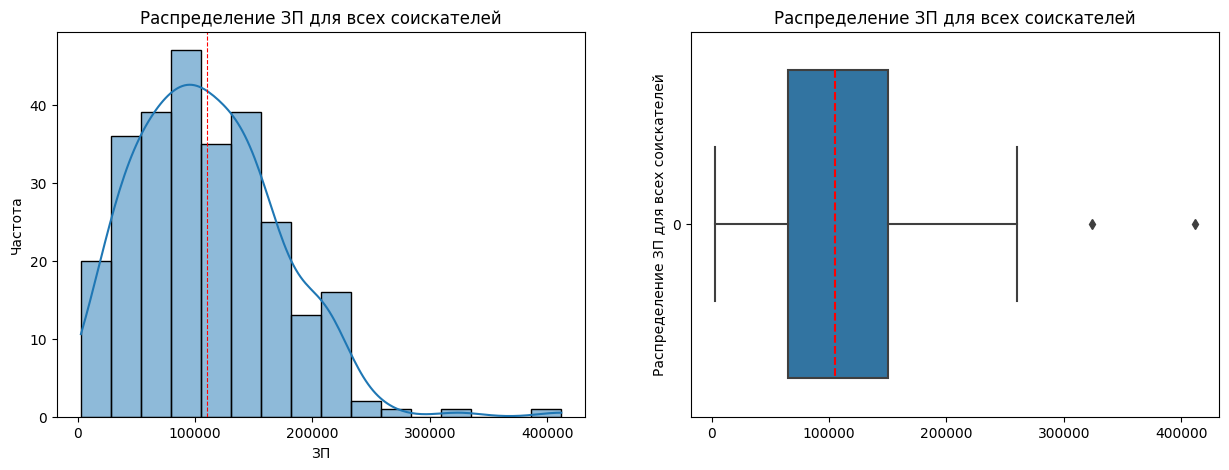

In [273]:
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

sns.histplot(df['salary_in_usd'], kde = True, ax = axes[0])
axes[0].set(xlabel = 'ЗП', ylabel = 'Частота')
axes[0].set_title('Распределение ЗП для всех соискателей')
axes[0].axvline(df['salary_in_usd'].mean(), color = 'red', linestyle = '--', linewidth=0.8)

sns.boxplot(df['salary_in_usd'], ax = axes[1], orient = 'h', medianprops = {"color": "red", "linestyle": '--'})
axes[1].set(ylabel = 'Распределение ЗП для всех соискателей')
axes[1].set_title('Распределение ЗП для всех соискателей')

plt.show()

In [274]:
#основные статистические характеристики для числового признака 'salary_in_usd'
display(df['salary_in_usd'].describe().round().to_frame())
display('mode meaning',round(st.mode(df['salary_in_usd']), 2))
display('median meaning',round(st.median(df['salary_in_usd']), 2))


,salary_in_usd
count,275.0
mean,110366.0
std,61018.0
min,2859.0
25%,65438.0
50%,104702.0
75%,150000.0
max,412000.0


'mode meaning'

100000

'median meaning'

104702

### Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?

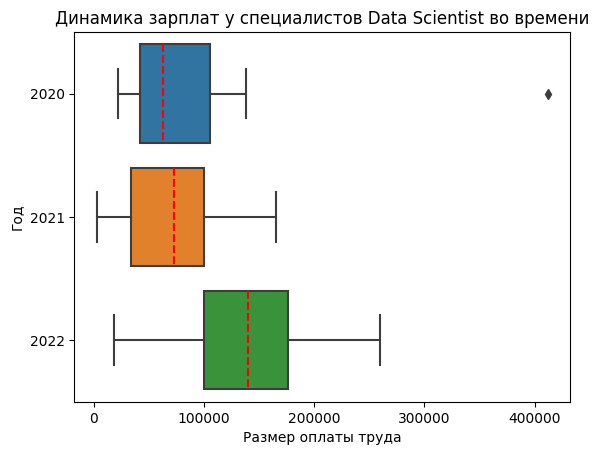

In [275]:
ax = sns.boxplot(df[df['job_title'] == 'Data Scientist'], x = 'salary_in_usd', y = 'work_year', orient = 'h', medianprops = {"color": "red", "linestyle": '--'})
ax.set(xlabel = 'Размер оплаты труда', ylabel = 'Год')
plt.title('Динамика зарплат у специалистов Data Scientist во времени')
plt.show()

In [276]:
df_agg = df[df['job_title'] == 'Data Scientist']
df_agg1 = df_agg.groupby('work_year')['salary_in_usd'].describe().round(2)
print('Уровень зарплат у специалистов Data Scientist во времени')
display(df_agg1)


Уровень зарплат у специалистов Data Scientist во времени


,count,mean,std,min,25%,50%,75%,max
work_year,,,,,,,,
2020,21.0,85970.52,81436.65,21669.0,42197.0,62726.0,105000.0,412000.0
2021,45.0,70671.73,45422.97,2859.0,33808.0,73000.0,100000.0,165000.0
2022,77.0,136172.09,54563.08,18442.0,100000.0,140000.0,176000.0,260000.0


Вывод: присутствует выброс равный 324000 K$. За его вычетом у специалистов Data Scientist наблюдается ежегодный рост зарплат. (столбец 50% соответствует медианному значению).

### Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году? 

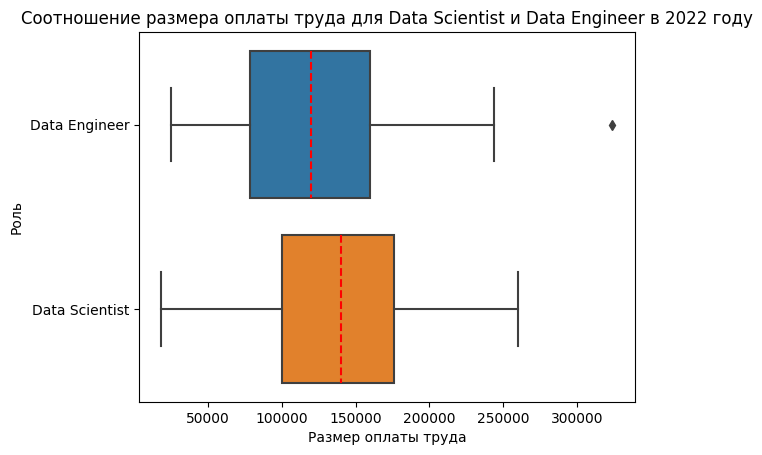

In [277]:
ax = sns.boxplot(df[df['work_year'] == 2022], x = 'salary_in_usd', y = 'job_title', orient = 'h', medianprops = {"color": "red", "linestyle": '--'})
ax.set(xlabel = 'Размер оплаты труда', ylabel = 'Роль')
plt.title('Соотношение размера оплаты труда для Data Scientist и Data Engineer в 2022 году')
plt.show()

In [278]:
df_agg = df[df['work_year'] == 2022]
df_agg = df_agg.groupby('job_title')['salary_in_usd'].describe().round(2)
print('Зависимость размера ЗП от опыта работы')
df_agg

Зависимость размера ЗП от опыта работы


,count,mean,std,min,25%,50%,75%,max
job_title,,,,,,,,
Data Engineer,89.0,126375.70,55954.40,25000.0,78526.0,120000.0,160000.0,324000.0
Data Scientist,77.0,136172.09,54563.08,18442.0,100000.0,140000.0,176000.0,260000.0


Вывод: в 2022 году среднее и медианное значения размера оплаты труда для Data Scientist выше чем для Data Engineer. 

### Зависимость размера ЗП от опыта работы

Text(0.5, 1.0, 'Распределение ЗП от опыта для Data Engineer')

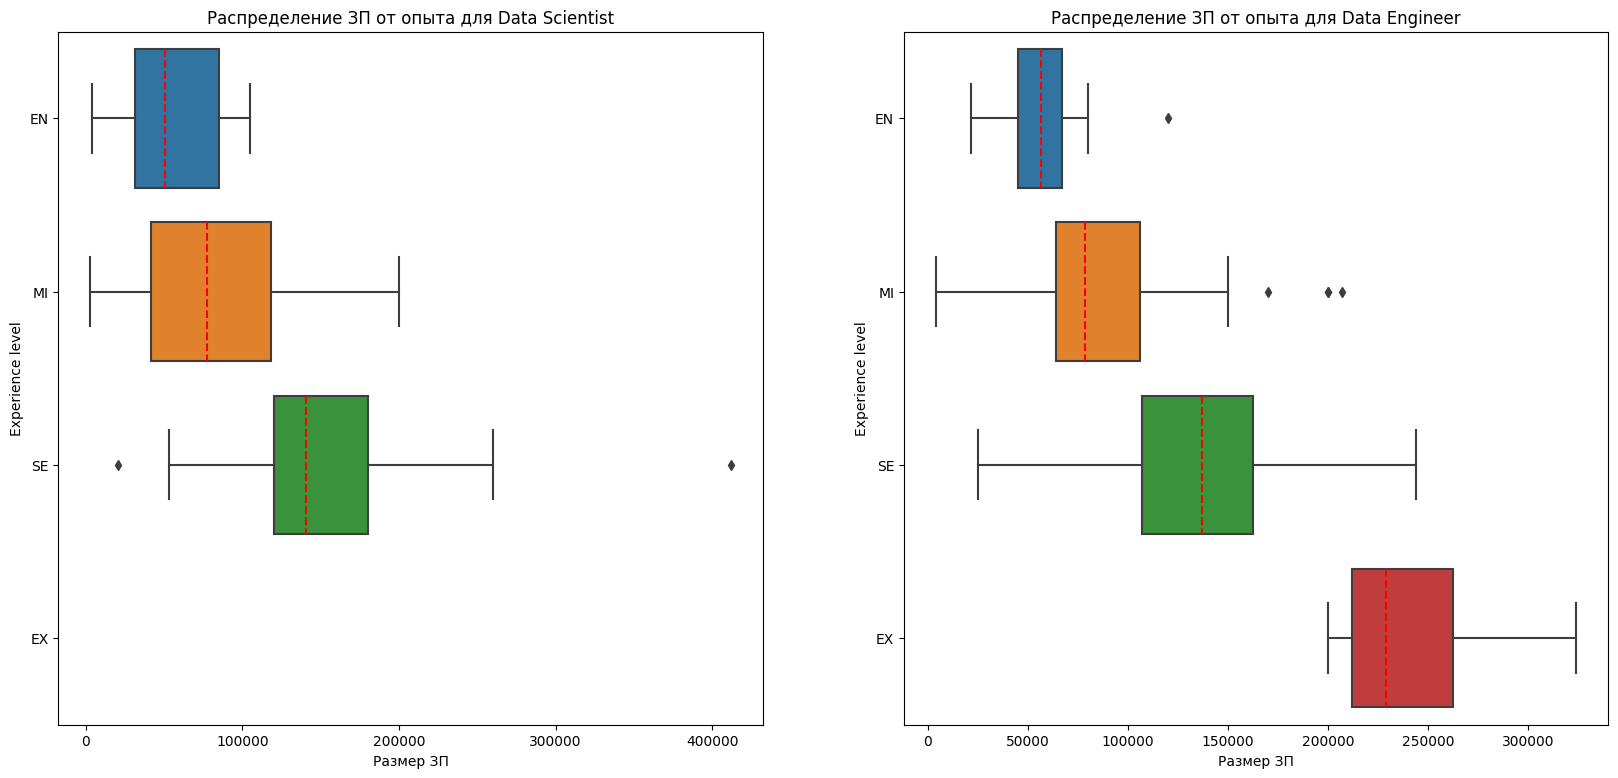

In [279]:
fig, axes = plt.subplots(1, 2, figsize = (20, 9))

sns.boxplot(df[df['job_title'] == 'Data Scientist'], x='salary_in_usd', y = 'experience_level', ax = axes[0], orient='h', medianprops = {"color": "red", "linestyle": '--'})
axes[0].set(xlabel = 'Размер ЗП', ylabel = 'Experience level')
axes[0].set_title('Распределение ЗП от опыта для Data Scientist')

sns.boxplot(df[df['job_title']=='Data Engineer'], x='salary_in_usd', y ='experience_level', ax = axes[1], orient='h', medianprops = {"color": "red", "linestyle": '--'})
axes[1].set(xlabel = 'Размер ЗП', ylabel = 'Experience level')
axes[1].set_title('Распределение ЗП от опыта для Data Engineer')

In [280]:
df_agg = df.groupby('experience_level')['salary_in_usd'].describe().round(2)
print('Зависимость размера ЗП от опыта работы')
df_agg

Зависимость размера ЗП от опыта работы


,count,mean,std,min,25%,50%,75%,max
experience_level,,,,,,,,
EN,34.0,56602.41,29002.78,4000.0,37461.25,52373.5,78125.0,120000.0
MI,113.0,83890.16,45603.07,2859.0,49461.00,78526.0,111775.0,206699.0
SE,124.0,144874.92,53508.67,20171.0,112375.00,140325.0,175025.0,412000.0
EX,4.0,245500.00,55121.08,200000.0,212000.00,229000.0,262500.0,324000.0


Распределения уровня заработной платы для Data Scientist и Data Engineer с разным опытом работы различны, но прослеживается прямая закономерность "больше опыта-выше ЗП". Т.К. для Data Scientist отсутствует статистика для Executive-level/Director, в следующем разделе мы проведём статистическое тестирование только для Data Engineer. В категориях Mid-level DE, Entry-level/Junior DE, Senior-level/Expert DS есть выбросы.

### Зависимость размера ЗП от вида занятости

Text(0.5, 1.0, 'Распределение ЗП от вида занятости для Data Engineer')

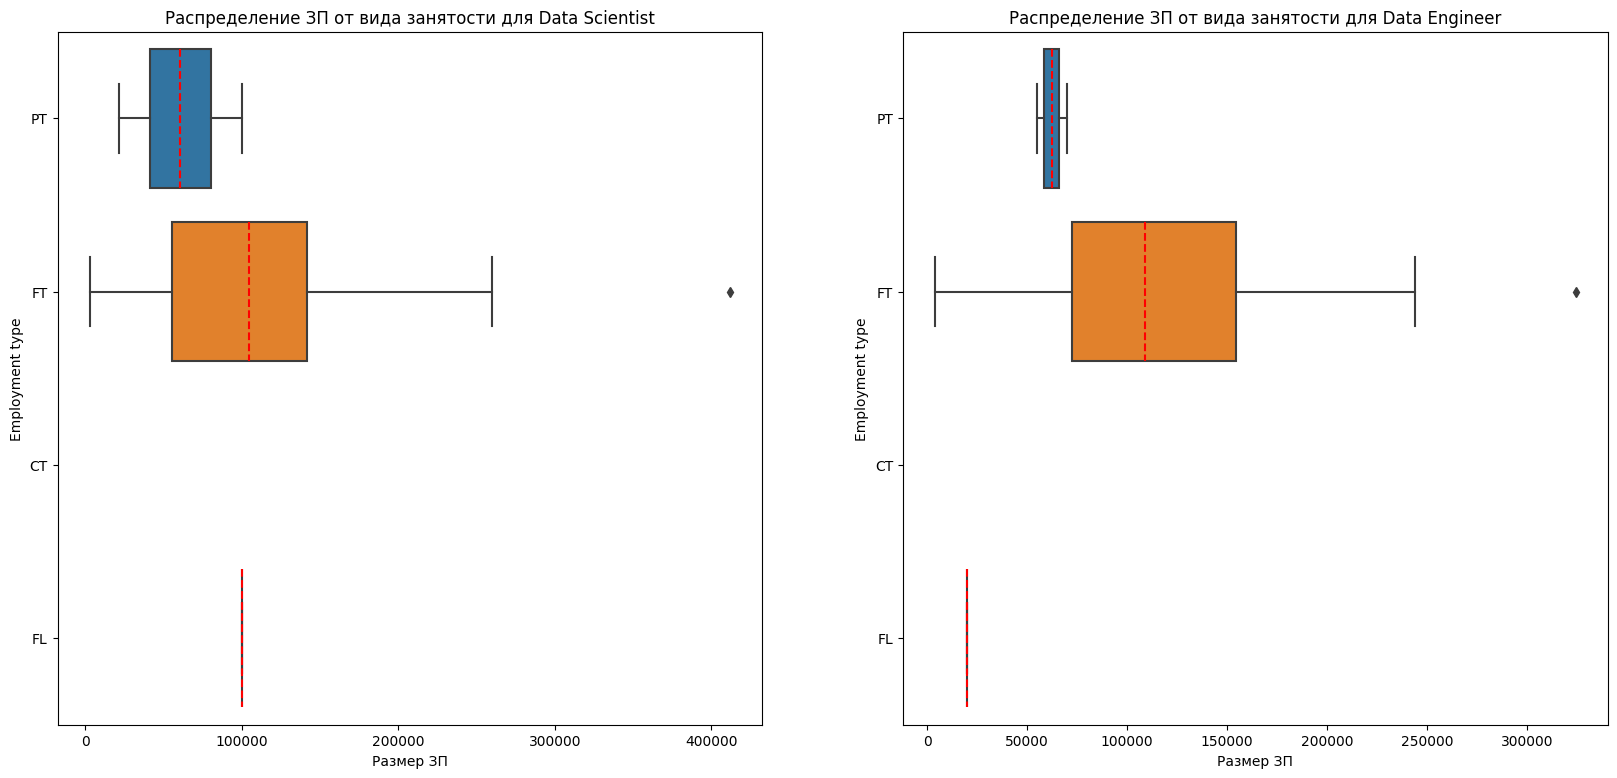

In [281]:
fig, axes = plt.subplots(1, 2, figsize = (20, 9))

sns.boxplot(df[df['job_title'] == 'Data Scientist'], x = 'salary_in_usd', y = 'employment_type', ax = axes[0], orient = 'h', medianprops = {"color": "red", "linestyle": '--'})
axes[0].set(xlabel = 'Размер ЗП', ylabel='Employment type')
axes[0].set_title('Распределение ЗП от вида занятости для Data Scientist')

sns.boxplot(df[df['job_title'] == 'Data Engineer'], x = 'salary_in_usd', y = 'employment_type', ax = axes[1], orient = 'h', medianprops = {"color": "red", "linestyle": '--'})
axes[1].set(xlabel = 'Размер ЗП', ylabel = 'Employment type')
axes[1].set_title('Распределение ЗП от вида занятости для Data Engineer')

In [282]:
df_agg = df.groupby('employment_type')['salary_in_usd'].describe().round(2)
print('Зависимость размера ЗП от вида занятости')
df_agg

Зависимость размера ЗП от вида занятости


,count,mean,std,min,25%,50%,75%,max
employment_type,,,,,,,,
PT,4.0,61591.75,32554.82,21669.0,46635.0,62349.0,77305.75,100000.0
FT,269.0,111465.40,61050.19,2859.0,65949.0,105000.0,150000.00,412000.0
CT,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FL,2.0,60000.00,56568.54,20000.0,40000.0,60000.0,80000.00,100000.0


Т.К. для Data Scientist и для Data Engineer полностью отсутствует статистика в категории контрактной работы, а количество данных в категориях фриланс и частичной занятости не значительно, то проведение статисческого тестирования нецелесообразно. Распределение уровня заработной платы от вида занятости различны. Для данного распределения прослеживаться закономерность "большее вовлечение-выше ЗП". В категории "полный рабочий день" есть выбросы. 

### Зависимость размера ЗП от объема работы, выполняемой удалённо

In [283]:
fig, axes = plt.subplots(1, 2, figsize = (22, 9))

sns.boxplot(df[df['job_title'] == 'Data Scientist'], x = 'salary_in_usd', y = 'remote_ratio', ax = axes[0], orient = h', medianprops = {"color": "red", "linestyle": '--'})
axes[0].set(xlabel = 'Размер ЗП', ylabel='Remote ratio')
axes[0].set_title('Распределение ЗП от объёма работы, выполняемой удалённо для Data Scientist')

sns.boxplot(df[df['job_title'] == 'Data Engineer'], x = 'salary_in_usd', y = 'remote_ratio', ax = axes[1], orient = 'h', medianprops = {"color": "red", "linestyle": '--'})
axes[1].set(xlabel = 'Размер ЗП', ylabel = 'Remote ratio')
axes[1].set_title('Распределение ЗП от объёма работы, выполняемой удалённо для Data Engineer')

SyntaxError: unterminated string literal (detected at line 3) (3892955306.py, line 3)

In [ ]:
df_agg = df.groupby('remote_ratio')['salary_in_usd'].describe().round(2)
print('Зависимость размера ЗП от объёма работы, выполняемой удалённо')
df_agg

Зависимость размера ЗП от объёма работы, выполняемой удалённо


,count,mean,std,min,25%,50%,75%,max
remote_ratio,,,,,,,,
0,66.0,100348.33,56707.51,2859.0,56475.0,96854.0,139300.0,220110.0
50,37.0,71593.70,32600.12,20171.0,49646.0,66022.0,90734.0,147000.0
100,172.0,122550.02,63296.48,4000.0,77739.5,120080.0,160000.0,412000.0


Для Data Scientist как и для Data Engineer зависимость размера ЗП от объёма работы, для полностью удаленного формата и для работы в офисе близки по значениям. Для категории 50%\50% медианный уровень ЗП ниже, чем в остальных категориях. В категории полностью удаленной работы есть выбросы для обеих ролей. Чтобы определить, являются ли различия в распределении статистически значимыми, в следующем разделе мы проведём статистическое тестирование для роли Data Scientist.

### Соотношение размера ЗП от размера компании роботодателя.

Text(0.5, 1.0, 'Распределение ЗП от размера компании роботодателя для Data Engineer')

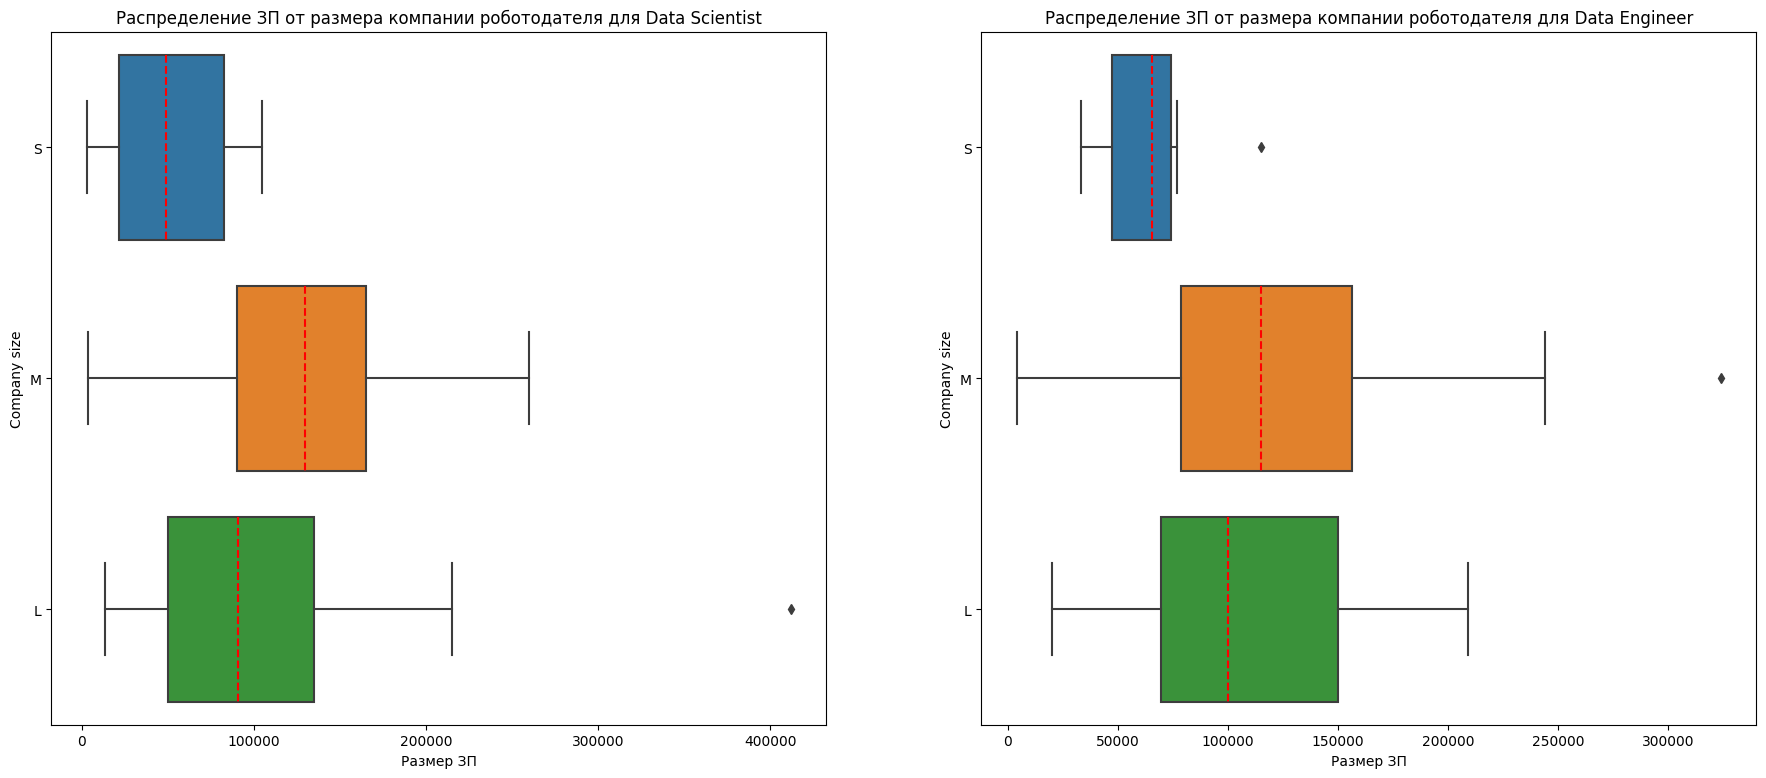

In [ ]:
fig, axes = plt.subplots(1, 2, figsize =( 22, 9))

sns.boxplot(df[df['job_title'] == 'Data Scientist'], x = 'salary_in_usd', y = 'company_size', ax = axes[0], orient = 'h', medianprops = {"color": "red", "linestyle": '--'})
axes[0].set(xlabel = 'Размер ЗП', ylabel = 'Company size')
axes[0].set_title('Распределение ЗП от размера компании роботодателя для Data Scientist')

sns.boxplot(df[df['job_title'] == 'Data Engineer'], x = 'salary_in_usd', y = 'company_size', ax = axes[1], orient = 'h', medianprops = {"color": "red", "linestyle": '--'})
axes[1].set(xlabel = 'Размер ЗП', ylabel = 'Company size')
axes[1].set_title('Распределение ЗП от размера компании роботодателя для Data Engineer')


In [ ]:
df_agg = df[df['job_title'] == 'Data Scientist']
df_agg = df_agg.groupby('company_size')['salary_in_usd'].describe().round(2)
print('Соотношение размера ЗП Data Scientist от размера компании роботодателя')
df_agg

Соотношение размера ЗП Data Scientist от размера компании роботодателя


,count,mean,std,min,25%,50%,75%,max
company_size,,,,,,,,
S,21.0,51925.76,33216.29,2859.0,21669.0,49268.0,82500.0,105000.0
M,77.0,126380.75,56389.53,4000.0,90000.0,130000.0,165000.0,260000.0
L,45.0,103313.36,71815.18,13400.0,50000.0,90734.0,135000.0,412000.0


Вывод: соотношение размера ЗП Data Scientist от размера компании роботодателя(штата сотрудников) распределена неравномерно. Максимальное значения медианной ЗП просматривается у организаций средного масштаба. Для крупных работодателей есть выбросы по предлагаемой ЗП. Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистическое тестирование для роли Data Scientist.

### Зависимость размера ЗП от местонахождения компании роботодателя и зависимость размера ЗП от местонахождения соискателя.

In [ ]:
print(df['employee_residence'].nunique())# смотрим кол-во уникальных значений
#создаем список тринадцати часто встречающихся стран
top_countries=df['employee_residence'].value_counts().nlargest(n = 13).to_dict()
top_countries=top_countries.keys()

#оставляем значимые страны остальные относим к other
df['employee_residence'] = df['employee_residence'].apply(lambda x: x if x in top_countries else 'Other')


33


In [ ]:
#тоже самое делаем для company_location
print(df['company_location'].nunique())# смотрим кол-во уникальных значений
#создаем список тринадцати часто встречающихся стран
top_countries=df['company_location'].value_counts().nlargest(n=13).to_dict()
top_countries=top_countries.keys()

#оставляем значимые страны остальные относим к other
df['company_location'] = df['company_location'].apply(lambda x: x if x in top_countries else 'Other')

29


Text(0.5, 1.0, 'Распределение ЗП от места проживания соискателей')

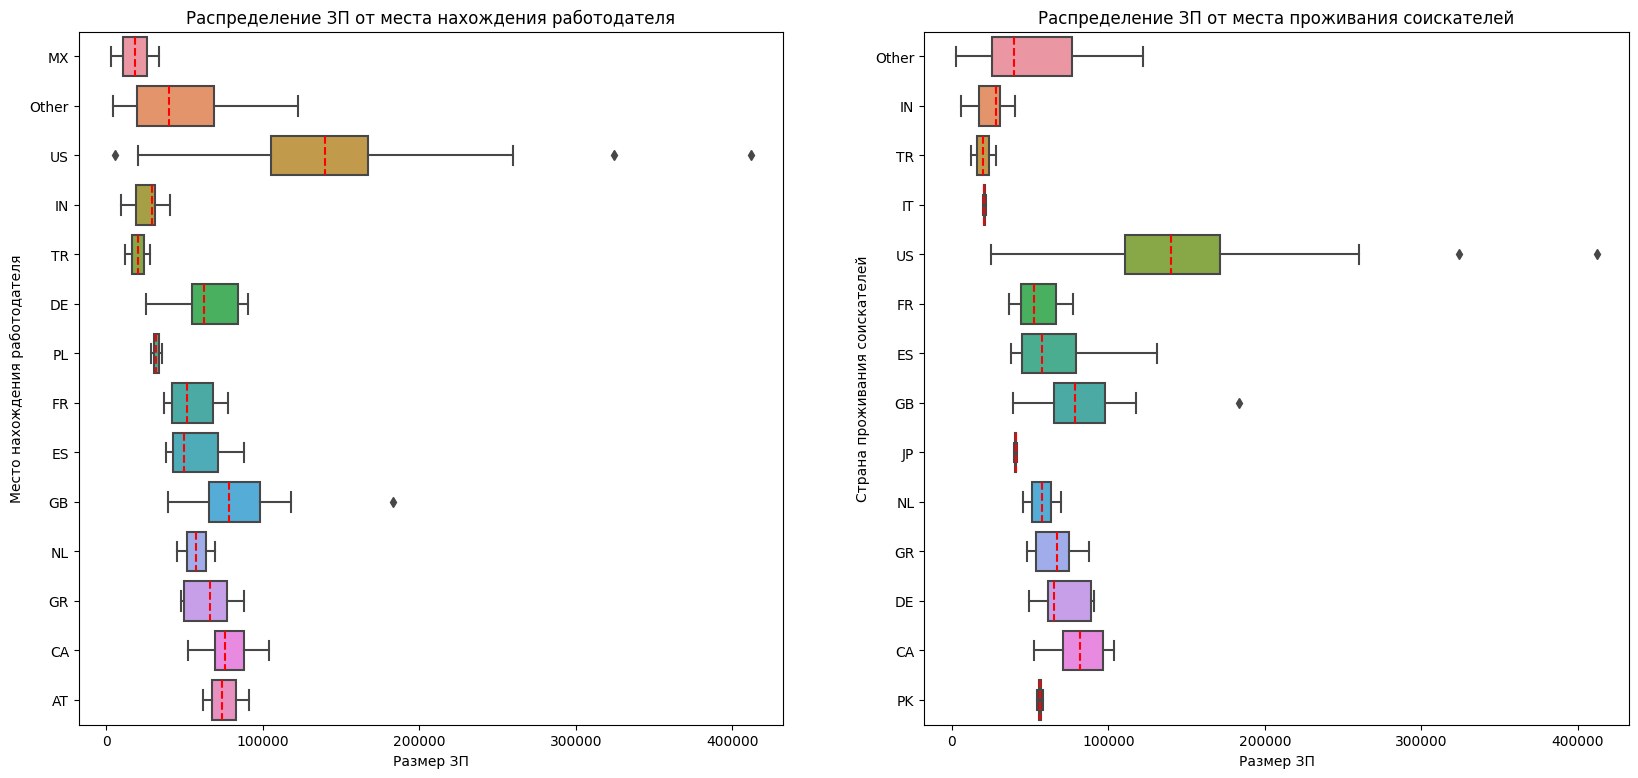

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (20, 9))

sns.boxplot(df.sort_values(by = 'salary_in_usd'), x ='salary_in_usd', y = 'company_location', ax = axes[0], orient='h', medianprops = {"color": "red", "linestyle": '--'})
axes[0].set(xlabel = 'Размер ЗП', ylabel = 'Место нахождения работодателя')
axes[0].set_title('Распределение ЗП от места нахождения работодателя')

sns.boxplot(df.sort_values(by = 'salary_in_usd'), x ='salary_in_usd', y = 'employee_residence', ax = axes[1], orient ='h', medianprops = {"color": "red", "linestyle": '--'})
axes[1].set(xlabel = 'Размер ЗП', ylabel = 'Страна проживания соискателей')
axes[1].set_title('Распределение ЗП от места проживания соискателей')

Основываясь на графиках выше, можно сделать следующие выводы:
- максимальный разброс по ЗП наблюдается у компаний лоцированных в США;
- максимальный разброс по ожиданиям ЗП наблюдается соискателей также из США;
- максимальный уровень ЗП на старте ожидают соискатели из Австрии;
- максимальный уровень ЗП на старте предлагают работодатели также из Австрии;
- максимальное медианное значение ЗП у соискателей и работодателей наблюдается в США.

### Соотношения Data Scientist и Data Engineer в категоряих experience_level, employment_type.

Text(0.5, 1.0, 'Соотношение Data Scientists и Data Engineers по виду занятости')

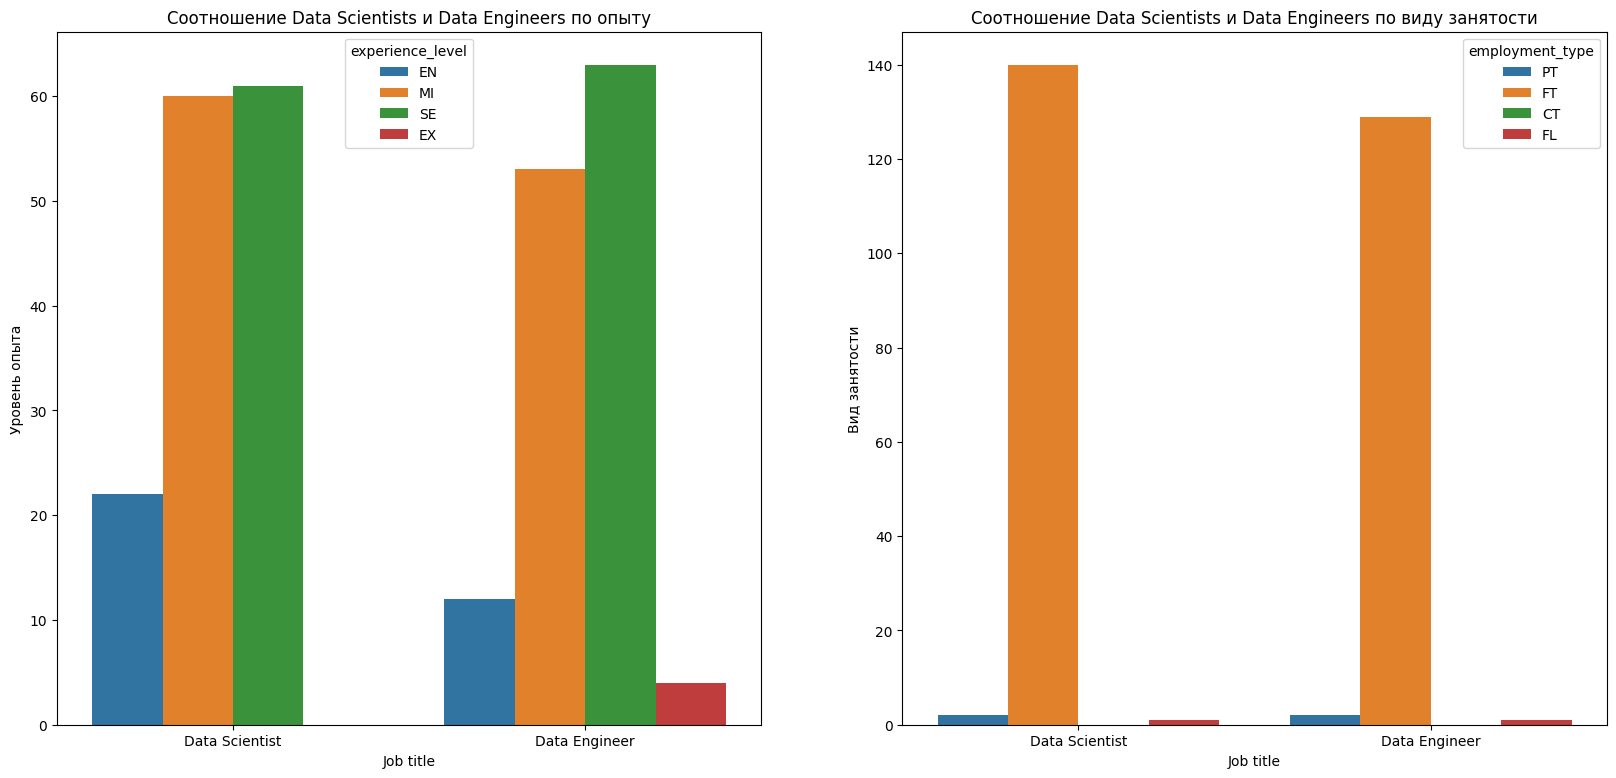

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

sns.countplot(df, x = 'job_title', hue = 'experience_level', ax = axes[0])
axes[0].set(xlabel = 'Job title', ylabel = 'Уровень опыта')
axes[0].set_title('Соотношение Data Scientists и Data Engineers по опыту')

sns.countplot(df, x = 'job_title', hue = 'employment_type', ax = axes[1])
axes[1].set(xlabel = 'Job title', ylabel = 'Вид занятости')
axes[1].set_title('Соотношение Data Scientists и Data Engineers по виду занятости')

Вывод: 
- по опыту работы для обеих ролей большая часть соискателей находятся в группах Mid-level/Intermediate и Senior-level/Expert, а в категории Executive-level/Director соискателей минимальное количество. Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистическое тестирование.
- по опыту работы для обеих ролей большая часть соискателей находятся в группе полной занятости, а в остальных категориях соискателей минимальное количество. Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистическое тестирование.

### Соотношения Data Scientist и Data Engineer в категоряих remote_ratio, company_size.

Remote ratio %:
 job_title       remote_ratio
Data Engineer   100             0.704545
                0               0.204545
                50              0.090909
Data Scientist  100             0.552448
                0               0.272727
                50              0.174825
Name: remote_ratio, dtype: float64
Company size %:
 job_title       company_size
Data Engineer   M               0.674242
                L               0.280303
                S               0.045455
Data Scientist  M               0.538462
                L               0.314685
                S               0.146853
Name: company_size, dtype: float64


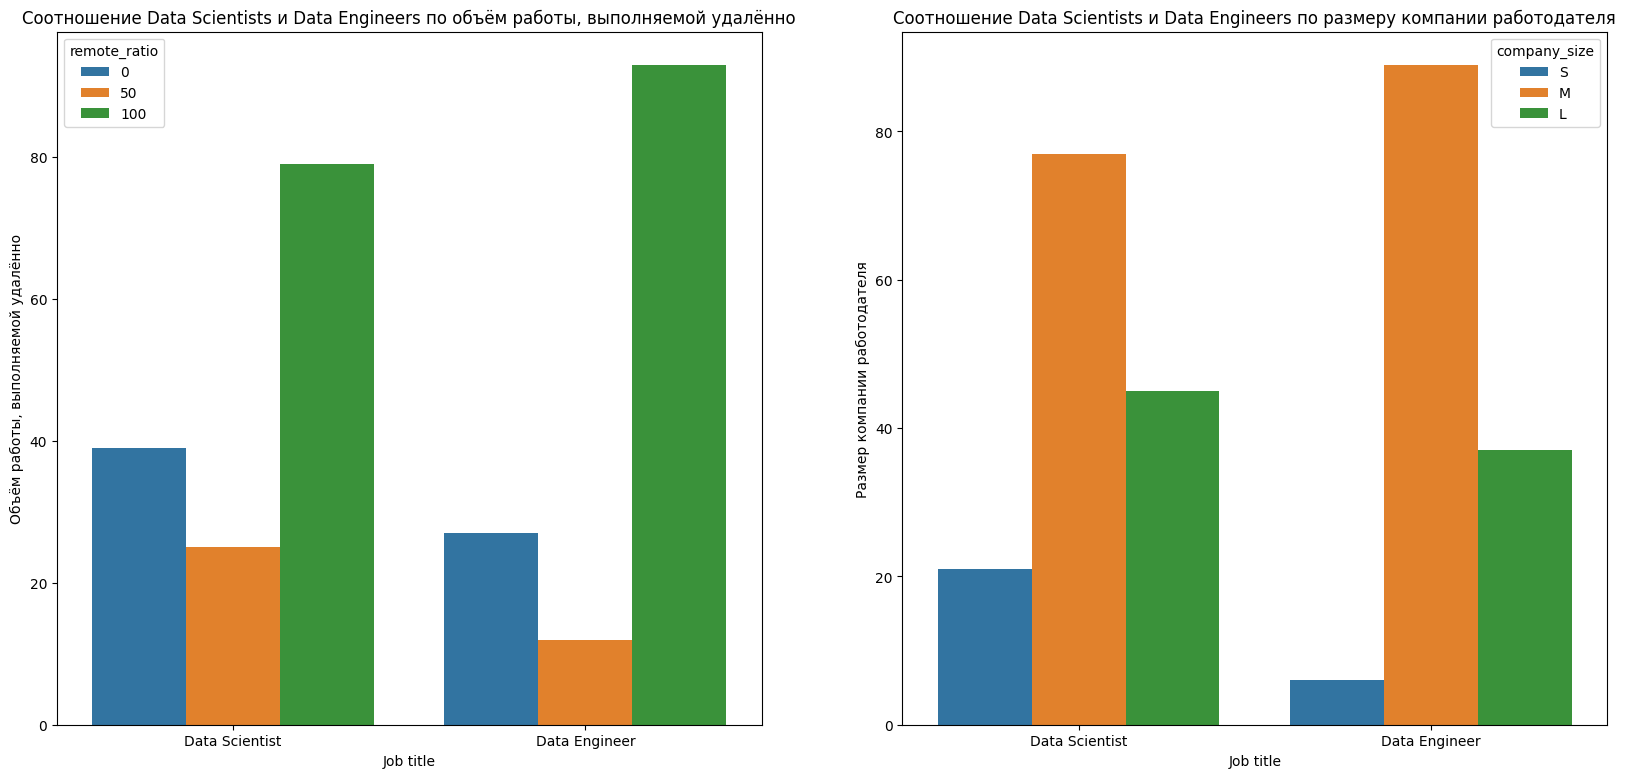

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (20, 9))

sns.countplot(df, x = 'job_title', hue = 'remote_ratio', ax = axes[0])
axes[0].set(xlabel = 'Job title', ylabel = 'Объём работы, выполняемой удалённо')
axes[0].set_title('Соотношение Data Scientists и Data Engineers по объём работы, выполняемой удалённо')

sns.countplot(df, x = 'job_title', hue = 'company_size', ax = axes[1])
axes[1].set(xlabel = 'Job title', ylabel = 'Размер компании работодателя')
axes[1].set_title('Соотношение Data Scientists и Data Engineers по размеру компании работодателя')

print('Remote ratio %:\n', df.groupby('job_title')['remote_ratio'].value_counts(normalize=True))
print('Company size %:\n', df.groupby('job_title')['company_size'].value_counts(normalize=True))

Вывод: 
- для обеих ролей более 55% соискателей находятся в группе с наибольшим объемом удаленной работы. Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистическое тестирование.
- для обеих ролей болtt 53% соискателей были трудоустроены в компниях среднего размера. Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистическое тестирование.

## Статистический анализ данных

In [ ]:
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


In [ ]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

### Размер заработной платы для Data Engineer больше, чем для Data Scientist??

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): размер заработной платы Data Engineer ($μ_1$) статистически меньше либо равен размеру страховых выплат Data Scientist ($μ_2$).

$$ H_0 : μ_1 <= μ_2$$

*Альтернативная гипотеза* ($H_1$): размер страховых выплат Data Engineer ($μ_1$) статистически больше, чем размер страховых выплат Data Scientist ($μ_2$).

$$ H_1 : μ_1 > μ_2$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально. Напомним гипотезы теста Шапиро-Уилка:

*Нулевая гипотеза* ($H_0$): распределение данные является нормальным.

*Альтернативная гипотеза* ($H_1$): распределение данных отлично от нормального.

In [ ]:
# значения заработной платы
Data_Engineer = df.loc[df['job_title'] == 'Data Engineer', 'salary_in_usd']
Data_Scientist = df.loc[df['job_title'] == 'Data Scientist', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для Data Engineer:')
result = stats.shapiro(Data_Engineer)
decision_normality(result[1])

print('Для Data Scientist:')
result = stats.shapiro(Data_Scientist)
decision_normality(result[1])

Для Data Engineer:
p-value = 0.010
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для Data Scientist:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Размер заработной платы»? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Чтобы проверить нашу гипотезу, можно использовать U-критерий Манна — Уитни для сравнения распределений на основе рангов.

**Проведём тест**

In [ ]:
# проводим тест
_, p = stats.mannwhitneyu(Data_Engineer, Data_Scientist, alternative='greater')
decision_hypothesis(p)

p-value = 0.234
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


**Вывод**

Нет оснований утверждать, что размер оплаты труда для Data Engineer больше, чем для Data Scientist.

### Влиянет ли опыт работы на размер ЗП для Data Engineer?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: размер ЗП не отличается от опыта работы: EN ($μ_1$), MI ($μ_2$), SE ($μ_3$), EX ($μ_4$).

$$ H_0 : μ_1 = μ_2 = μ_3 = μ_4$$

*Альтернативная гипотеза*: размер ЗП отличается от опыта работы: EN ($μ_1$), MI ($μ_2$), SE ($μ_3$), EX ($μ_4$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3 \neq μ_4$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [ ]:
# значения ЗП
salary_en = df.loc[(df['experience_level'] == 'EN') & (df['job_title'] == 'Data Engineer'), 'salary_in_usd']
salary_mi = df.loc[(df['experience_level'] == 'MI') & (df['job_title'] == 'Data Engineer'), 'salary_in_usd']
salary_se = df.loc[(df['experience_level'] == 'SE') & (df['job_title'] == 'Data Engineer'), 'salary_in_usd']
salary_ex = df.loc[(df['experience_level'] == 'EX') & (df['job_title'] == 'Data Engineer'), 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для EN:')
result = stats.shapiro(salary_en)
decision_normality(result[1])

print('Для MI:')
result = stats.shapiro(salary_mi)
decision_normality(result[1])

print('Для SE:')
result = stats.shapiro(salary_se)
decision_normality(result[1])

print('Для EX:')
result = stats.shapiro(salary_ex)
decision_normality(result[1])

Для EN:
p-value = 0.443
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для MI:
p-value = 0.011
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для SE:
p-value = 0.838
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для EX:
p-value = 0.337
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Experience level»? — Количественный.
* Сколько сравниваемых групп? — Четыре.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет&Да. 

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест**

In [ ]:
# проводим тест
_, p = stats.kruskal(salary_en, salary_mi, salary_se, salary_ex)
decision_hypothesis(p)


p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

У нас есть основания утверждать, что опыт работы влияет на размер ЗП для Data Engineer.

### Зависит ли размер ЗП от объема работы, выполняемой удалённо?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: размер ЗП не отличается от объема работы, выполняемой удалённо: 0% ($μ_1$), 50% ($μ_2$), 100% ($μ_3$).

$$ H_0 : μ_1 = μ_2 = μ_3 $$

*Альтернативная гипотеза*: размер ЗП отличается от объема работы, выполняемой удалённо: 0% ($μ_1$), 50% ($μ_2$), 100% ($μ_3$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [ ]:
# значения ЗП
salary_0 = df.loc[(df['remote_ratio'] == 0) & (df['job_title'] == 'Data Scientist'), 'salary_in_usd']
salary_50 = df.loc[(df['remote_ratio'] == 50) & (df['job_title'] == 'Data Scientist'), 'salary_in_usd']
salary_100 = df.loc[(df['remote_ratio'] == 100) & (df['job_title'] == 'Data Scientist'), 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для 0%:')
result = stats.shapiro(salary_0)
decision_normality(result[1])

print('Для 50%:')
result = stats.shapiro(salary_50)
decision_normality(result[1])

print('Для 100%:')
result = stats.shapiro(salary_100)
decision_normality(result[1])


Для 0%:
p-value = 0.363
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для 50%:
p-value = 0.482
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для 100%:
p-value = 0.002
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака "Remote ratio"? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет&Да. 

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест**

In [ ]:
# проводим тест
_, p = stats.kruskal(salary_0, salary_50, salary_100)
decision_hypothesis(p)

p-value = 0.002
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

У нас есть основания утверждать, что объем работы, выполняемой удалённо влияет на размер ЗП для Data Scientist.

### Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров??

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: размер ЗП не отличается от размера компании роботодателя: S ($μ_1$), M ($μ_2$), L ($μ_3$).

$$ H_0 : μ_1 = μ_2 = μ_3 $$

*Альтернативная гипотеза*: размер ЗП отличается от размера компании роботодателя: S ($μ_1$), M ($μ_2$), L ($μ_3$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [ ]:
# значения ЗП
salary_S = df.loc[(df['company_size'] == 'S') & (df['job_title'] == 'Data Scientist'), 'salary_in_usd']
salary_M = df.loc[(df['company_size'] == 'M') & (df['job_title'] == 'Data Scientist'), 'salary_in_usd']
salary_L = df.loc[(df['company_size'] == 'L') & (df['job_title'] == 'Data Scientist'), 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для S:')
result = stats.shapiro(salary_S)
decision_normality(result[1])

print('Для M:')
result = stats.shapiro(salary_M)
decision_normality(result[1])

print('Для L:')
result = stats.shapiro(salary_L)
decision_normality(result[1])

Для S:
p-value = 0.189
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для M:
p-value = 0.639
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для L:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака "Company size"? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет&Да. 

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест

In [ ]:
# проводим тест
_, p = stats.kruskal(salary_S, salary_M, salary_L)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

У нас есть основания утверждать, что размер компании роботодателя влияет на размер ЗП для Data Scientist.

### Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: между наличием роли и размером компании работодателя нет взаимосвязи (признаки независимы).

*Альтернативная гипотеза*: между наличием роли и размером компании работодателя есть взаимосвязь (признаки зависимы).

**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «роль»? — Категориальный.
* Сколько сравниваемых групп? — Две.
* Проверяется независимость групп? — Да.

Для проверки нашей гипотезы можно использовать критерий ${\chi}^2$ (хи-квадрат).

**Проведём тест**

In [ ]:
# составляем таблицу сопряжённости
cross_table = pd.crosstab(df['job_title'], df['company_size'])

cross_table

company_size,S,M,L
job_title,,,
Data Engineer,6,89,37
Data Scientist,21,77,45


In [ ]:
# проводим тест
_, p, _, _ = stats.chi2_contingency(cross_table)
decision_hypothesis(p)

p-value = 0.008
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Существует статистически значимая взаимосвязь между наличем роли и размером компании работодателя.

## Итоговые результаты исследования

*   У специалистов Data Scientist наблюдается ежегодный рост зарплат.
*   В 2022 году среднее и медианное значения размера оплаты труда для Data Scientist выше чем для Data Engineer.
*   Соотношение размера ЗП Data Scientist от размера компании роботодателя(штата сотрудников) распределена неравномерно. Максимальное значения медианной ЗП просматривается у организаций средного масштаба. На основании статистического теста у нас есть право утверждать, что размер компании роботодателя влияет на размер ЗП для Data Scientist.
*   Существует статистически значимая взаимосвязь между наличем роли и размером компании работодателя.